# Sprint 19 - Aprendizaje por Refuerzo (Sesiones)

En este caso de estudio realizaremos una introducción a los modelos basados en **Aprendizaje por refuerzo**, una de las ramas más importantes y prometedoras de la ciencia de datos e inteligencia artificial moderna. A diferencia de los modelos supervisados que aprenden a partir de ejemplos etiquetados, o de los modelos no supervisados que buscan descubrir patrones ocultos en los datos, el aprendizaje por refuerzo se enfoca en enseñar a una entidad a tomar decisiones mediante la interacción directa con un entorno, permitiendo que dicha entidad aprenda progresivamente cuáles son las acciones más convenientes para alcanzar una meta específica.

La idea fundamental detrás de este paradigma se inspira en una forma de aprendizaje ampliamente utilizada por los seres humanos y muchos organismos vivos: la prueba y error. Cuando una persona enfrenta una situación nueva, suele experimentar distintas acciones, observar sus consecuencias y modificar su comportamiento en función de los resultados obtenidos. Las decisiones que generan resultados positivos tienden a repetirse, mientras que aquellas que producen consecuencias desfavorables suelen descartarse. El **Aprendizaje por refuerzo** replica esta lógica mediante mecanismos de recompensas y penalizaciones, permitiendo que la entidad desarrolle estrategias cada vez más efectivas a medida que acumula experiencia.

Dentro de este enfoque aparecen conceptos fundamentales como el agente, que representa la entidad que toma decisiones; el entorno, que describe el escenario donde dichas decisiones ocurren; los estados, que caracterizan la situación actual del entorno; las acciones, que representan las posibles decisiones del agente; y las recompensas, que cuantifican qué tan beneficioso fue el resultado obtenido. El desafío principal consiste en encontrar una política de actuación que maximice la recompensa acumulada a largo plazo, incluso cuando las consecuencias de una decisión no sean inmediatas.

Una de las características más interesantes del **Aprendizaje por refuerzo** es que puede desarrollarse sin la necesidad de disponer de grandes conjuntos de datos históricos previamente etiquetados. En lugar de aprender de observaciones pasadas, el agente genera su propio conocimiento a través de la interacción continua con el entorno. Gracias a ello, esta metodología resulta especialmente útil en problemas donde las condiciones cambian dinámicamente o donde resulta difícil disponer de ejemplos que describan explícitamente cuál es la mejor decisión en cada situación.

Estas capacidades han convertido al **Aprendizaje por refuerzo** en una herramienta de enorme relevancia para múltiples aplicaciones. Actualmente se utiliza en sistemas de recomendación, optimización logística, robótica, automatización industrial, control de procesos, videojuegos, vehículos autónomos y planificación estratégica, entre muchos otros campos. De hecho, algunos de los avances más conocidos de la inteligencia artificial en los últimos años, como agentes capaces de superar a expertos humanos en juegos complejos, han sido posibles gracias a técnicas derivadas de este paradigma.

Para comprender adecuadamente estos conceptos, en este caso comenzaremos construyendo un entorno computacional que represente una situación simplificada del mundo real. Este entorno servirá como escenario de experimentación donde los agentes podrán interactuar, tomar decisiones y recibir retroalimentación sobre sus acciones. Durante este proceso introduciremos también un concepto fundamental de programación orientada a objetos en **Python**: las clases. Una herramienta que permite modelar entidades y comportamientos de manera estructurada, facilitando el desarrollo de programas más organizados, reutilizables y escalables.

Posteriormente implementaremos un algoritmo clásicoa de **Aprendizaje por refuerzo** que permita a nuestros agentes descubrir estrategias óptimas dentro del entorno diseñado. Analizaremos cómo aprenden, cómo equilibran la exploración de nuevas alternativas frente al aprovechamiento de conocimientos previos y cómo evolucionan sus decisiones a medida que acumulan experiencia. De esta manera, no solo incorporaremos una nueva familia de técnicas de ciencia de datos e inteligencia artificial, sino que también fortaleceremos nuestras habilidades de programación y nuestra comprensión de los mecanismos que permiten a las máquinas aprender a tomar decisiones de forma autónoma.

## Entendimiento del contexto

La industria automotriz se caracteriza por operar en entornos altamente dinámicos y competitivos, donde la incorporación de nuevas tecnologías en sus productos se constituye en un factor clave para mantener la rentabilidad y satisfacer las crecientes exigencias del mercado. En este contexto, las empresas fabricantes de vehículos desde hace aproximadamente una década buscan adaptar inteligencia artificial que les permita entre otras cosas, desarrollar sistemas autónomos de pilotaje automático, garantizando con esto no solamente la comodidad de sus clientes, sino también su seguridad en los traslados diarios que realizan.

Con el propósito de explorar nuevas alternativas al respecto, una empresa fabricante de vehículos ha decidido impulsar un proyecto piloto orientado al desarrollo de un modelo basado en **Aprendizaje por refuerzo** para la creación de un sistema inteligente que indique la ruta que debe seguir un vehículo hacia un destino específico. Si este modelo funciona, la compañía podría abrir las puertas a nuevas iniciativas complementarios que le permitan en última instancia contar con productos completamente autónomos en los próximos años.

El objetivo específico del proyecto consiste en diseñar, entrenar y evaluar un modelo capaz de identificar la mejor ruta desde un punto de origen donde se encuentra el vehículo, hasta un punto de destino cualquiera dentro de una ciudad. Para ello, se plantea inicialmente la construcción de un entorno de simulación que represente de manera simplificada pero realista las condiciones de la urbe, y a continuación la generación de una estrategia óptima a ejecutar por el vehículo.

Evidentemente, el desarrollo de una solución de esta naturaleza requiere conocimientos especializados en ciencia de datos y aprendizaje automático,  por lo que la empresa ha identificado la conveniencia de contratarte para liderar el diseño, desarrollo y validación del modelo piloto. Serás responsable de comprender el problema de negocio, preparar los datos necesarios, construir el entorno de simulación, seleccionar los algoritmos más adecuados y evaluar el desempeño de las soluciones propuestas, contribuyendo así a determinar la viabilidad de una futura implementación a escala dentro de la organización.

## Creación de entorno computacional

Antes todo y como lo hemo venido haciendo, conviene que cargues las siguientes librerias:

* **Pandas**, **numpy** y **matplotlib**.
* La librería **gymnasium** que permite crear y definir entornos para **Aprendizaje por refuerzo**.
* Las función `defaultdict` de la libreria **collections** que permiten crear diccionarios "dinámicos" que nos serán útiles al entrenar nuestro modelo.

In [1]:
# Cargar librerias para manipulacion y visualizacion de datos
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Cargar librerias para modelamiento 
import gymnasium as gym # Se debe instalar gymnasium y "gymnasium[classic-control]"
from collections import defaultdict

### Existencia y comportamiento del entorno como funciones

En el contexto del **Arendizaje por refuerzo** podemos entender un **Entorno** como una representación de un caso real en un momento del tiempo dado, y que fundamentalmente posee 3 características:

* **Agentes**: entidades que existen y pueden ejecutar acciones dentro del entorno.
* **Acciones**: decisiones que tienen permitido ejecutar los agentes en cada momento del tiempo. Estas acciones están definidas en un *espacio* en el sentido matemático, y tienen una *representación* en el contexto del entorno.  
* **Espacio de estados**: todas las situaciones posibles del entorno en un momento del tiempo especifico que dependen de las acciones que ejecuten los agentes y que pueden ser observados por ellos.

Además y sin perjuicio de lo anterior, igualmente un entorno puede tener otras características específicas dependiendo de la circunstancia. Por ejemplo en este caso, podríamos considerar el tamaño de la ciudad y el momento del tiempo.

Visto esto, vamos a crear como entorno de este proyecto una "micro-ciudad" con calles horizonales y verticales que se crucen en intersecciones, y que cuente con todas las características mencionadas antes. Define con este propósito la función `cityenv` que reciba como entrada un tamaño de ciudad específico y que devuelva a modo de diccionario lo siguiente: 

* El tamaño de la ciudad como un valor entero.
* El momento de tiempo definido por el valor constante 0.
* Dos agentes (un vehículo y un destino objetivo) representados como vectores de posición $(x,y)$, donde estos valores correspondan al valor medio del tamaño de la ciudad.
* Cuatro posibles acciones de movimiento del vehículo (moverse hacia el este, norte, oeste o sur) y sus representaciones en el entorno. Utiliza para esto la funcion `spaces.Discrete` de **gymnasium**.
* Un espacio de estados que refleje las posiciones de los agentes en el estado en un momento de tiempo dado. Utiliza para esto las funciones `spaces.Dict` y `spaces.Box` de **gymnasium**.

In [2]:
# Generar funcion que define un entorno en un momento dado 
def cityenv (size = 10):

    # Definir tamaño y tiempo
    size = int(size)
    time = 0

    # Definir agentes (vehiculo y objetivo)
    vehicle = np.array([size // 2, size // 2])
    target = np.array([size // 2, size // 2])

    # Definir acciones posibles
    action_space = gym.spaces.Discrete(4)
    action_representation = {
        0: np.array([1,0]), # Movimiento hacia el este
        1: np.array([0,1]), # Movimiento hacia el norte
        2: np.array([-1,0]), # Movimiento hacia el oeste
        3: np.array([0,-1]), # Movimiento hacia el sur
    }

    # Definir estados posibles (lo que observa el agente)
    state_space = gym.spaces.Dict(
            {
                "agent": gym.spaces.Box(
                    low = 0, 
                    high = size - 1, 
                    shape = (2,), 
                    dtype = int
                ),   
                "target": gym.spaces.Box(
                    low = 0, 
                    high = size - 1, 
                    shape = (2,), 
                    dtype = int
                )
            }
        )

    # Consolidar informacion de entorno en diccionario
    dic_environment = dict(
        size = size,
        time = time,
        vehicle = vehicle, 
        target = target,
        action_space = action_space, 
        action_representation = action_representation,
        state_space = state_space
    ) 

    return dic_environment

# Probar funcion
env = cityenv(size = 10)
env

{'size': 10,
 'time': 0,
 'vehicle': array([5, 5]),
 'target': array([5, 5]),
 'action_space': Discrete(4),
 'action_representation': {0: array([1, 0]),
  1: array([0, 1]),
  2: array([-1,  0]),
  3: array([ 0, -1])},
 'state_space': Dict('agent': Box(0, 9, (2,), int64), 'target': Box(0, 9, (2,), int64))}

Definamos ahora todo aquello que permita gestionar el comportamiento de los agentes en el entorno. Como mecanismos auxiliares, genera las siguientes funciones: 

* `get_state` que devuelve un diccionario con el estado vigente del entorno, esto es, las "posiciones" de los agentes.
* `get_dist` que devuelve la distancia "Manhattan" entre los agentes dentro de la ciudad. Usamos esta distancia porque, como dijimos, nuestra "micro-ciudad" esta conformada solamente por calles horizontales y verticales a modo de grilla.

In [3]:
# Definir funcion que devuelva el estado del entorno
def get_state(environment):
    return {"vehicle": environment["vehicle"], "target": environment["target"]}

# Probar funcion
get_state(env)

{'vehicle': array([5, 5]), 'target': array([5, 5])}

In [4]:
# Definir funcion que devuelva la distancia manhattan entre agentes
def get_dist(environment):
    return np.linalg.norm(environment["vehicle"] - environment["target"], ord = 1)

# Probar funcion
get_dist(env)

np.float64(0.0)

Necesitamos inicializar realmente nuestra "micro-ciudad". En concreto requerimos que los agentes (vehículo y objetivo) estén en algún lado efectivamente, por lo que debes crear la funcion `initialize` que tome el entorno creado y partir de allí ejecute las siguientes tareas: 

* Asegurar que el momento de tiempo sea 0.
* Colocar en lugares distintos tanto al vehículo como al objetivo. 
* Devolver el estado alcanzado y la distancia entre los agentes, para lo cual puedes usar las funciones y definidas. 

In [5]:
# Definir funcion de inicializacion
def initialize(environment):

    # Asegurar tiempo en 0
    environment["time"] = 0

    # Colocar el vehiculo en cualquier lugar de la ciudad
    environment["vehicle"] = np.random.randint(
        low = 0, 
        high = environment["size"], 
        size = 2
    )

    # Colocar el objetivo en cualquier lugar de la ciudad que no sea donde ya esta el agente
    environment["target"] = environment["vehicle"]
    while np.array_equal(environment["target"], environment["vehicle"]):
        environment["target"] = np.random.randint(
            low = 0, 
            high = environment["size"], 
            size = 2
        )

    # Calcular estado y distancia
    state = get_state(environment)
    distance = get_dist(environment)

    return state, distance

In [6]:
# Probar funcion
state, dist = initialize(env)
print(f"Estado: {state}")
print(f"Distancia: {dist:.1f}")

Estado: {'vehicle': array([1, 3], dtype=int32), 'target': array([3, 4], dtype=int32)}
Distancia: 3.0


In [7]:
# Verificar inicializacion del entorno
env

{'size': 10,
 'time': 0,
 'vehicle': array([1, 3], dtype=int32),
 'target': array([3, 4], dtype=int32),
 'action_space': Discrete(4),
 'action_representation': {0: array([1, 0]),
  1: array([0, 1]),
  2: array([-1,  0]),
  3: array([ 0, -1])},
 'state_space': Dict('agent': Box(0, 9, (2,), int64), 'target': Box(0, 9, (2,), int64))}

Solamente nos falta establecer qué puede suceder en un momento del tiempo dado. Crea para esto la función `step` que tome el entorno y una de las 4 posibles acciones (0, 1, 2, 3), para con estos insumos movilizar al vehiculo en base a la dirección establecida por dicha acción. Una vez hecho esto la función debe: 

* Verificar si con el movimiento realizado se alcanzó el objetivo y guardar el resultado en una variable buleana.
* Actualizar el tiempo del entorno con una unidad adicional, 
* Verificar que este tiempo no supere una cuarta parte del cuadrado del tamaño de la ciudad (tiempo límite).
* Definir una recompensa que tome el valor de 1 si se alcanzó el objetivo, y en todos los demás casos sea 0.
* Calcular el estado y la distancia entre los agentes.

Realizado todo esto, la función debe devolver en este orden los siguientes valores: el estado alcanzado, la recompensa, si se alcanzó el objetivo, si se alcanzó el tiempo limite, la distancia.

In [8]:
# Definir funcion para establecer sucesos
def step(environment, action):
    
    # Establecer direccion del movimiento seleccionado
    direction = environment["action_representation"][action]

    # Actualizar posicion del agente
    environment["vehicle"] = np.clip( # la funcion clip permite evitar que agente salga del grid
        environment["vehicle"] + direction, 
        a_min = 0, 
        a_max = environment["size"] - 1
    )

    # Verificar si se alcanzo objetivo
    end_steps = np.array_equal(environment["vehicle"], environment["target"])

    # Actualizar el tiempo y verificar si se alcanza el limite
    environment["time"] = environment["time"] + 1
    end_time = environment["time"] >= environment["size"] ** 2 // 4

    # Establecer recompensa
    reward = 1 if end_steps else 0

    # Calcular estado y distancia
    state = get_state(environment)
    distance = get_dist(environment)

    return state, reward, end_steps, end_time, distance

In [9]:
# Probar funcion
state, reward, end_steps, end_time, dist = step(env, 0)
print(f"Estado: {state}")
print(f"Recompensa: {reward:.0f}")
print(f"Se alcanza objetivo: {end_steps}")
print(f"Se alcanza el tiempo limite: {end_time}")
print(f"Distancia: {dist:.1f}")

Estado: {'vehicle': array([2, 3]), 'target': array([3, 4], dtype=int32)}
Recompensa: 0
Se alcanza objetivo: False
Se alcanza el tiempo limite: False
Distancia: 2.0


In [10]:
# Verificar actualizacion del entorno
env

{'size': 10,
 'time': 1,
 'vehicle': array([2, 3]),
 'target': array([3, 4], dtype=int32),
 'action_space': Discrete(4),
 'action_representation': {0: array([1, 0]),
  1: array([0, 1]),
  2: array([-1,  0]),
  3: array([ 0, -1])},
 'state_space': Dict('agent': Box(0, 9, (2,), int64), 'target': Box(0, 9, (2,), int64))}

### Existencia y comportamiento del entorno como clase

Ya tenemos todo lo necesario para garantizar que nuestra "micro-ciudad" exista y funcione adecuadamente. 

Ahora bien, una manera eficiente de consolidar todo lo definido es mediante la generación de un objeto de tipo `class`, donde cada una de estas funciones puede volverse un método de esta *clase*. La sintaxis básica en **Python** para este objeto es el descrito a continuación:

```py
class nombre_de_la_clase ():

    """Definicion de la clase"""
    def __init__ (self, entradas_de_la_clase):
        # Codigo que defina los principales atributos de la clase
    
    """Metodos propios de esta clase con la sintaxis de funcion"""
    def nombre_del_metodo_1 (self, entradas_del_metodo_1):
        #Código del metodo 1
        return salidas

    def nombre_del_metodo_1 (self, entradas_del_metodo_2):
        #Código del metodo 2
        return salidas
```

La variable `self` que observas en cada componente de este código ilustrativo es la forma que **Python** tiene de representar a la clase en su misma definición. No te preocupes si aún te es díficil comprender lo que significa esta idea, ya que a continuación definiremos nuestro entorno como un objeto tipo `class`.   

Algo adicional que debes saber, es que una vez generada, se puede llamar y guardar a la clase con el código 

```py
variable = nombre_de_la_clase(entradas_de_la_clase)
```

Y a sus distintos métodos con el código

```py
variable.nombre_del_metodo_X(entradas_del_metodo_X)
```

Si te pones a pensar, todos los algoritmos de **Scikit-Learn** que has aprendido son estrictamente *clases* con sus propios métodos. Cuando creas, entrenas y predices con un modelo con Regresion Lineal por ejemplo, ejecutas lo siguiente:

```py
# Crear modelo == Llamar y guardar a la clase
modelo = LinearRegression(fit_intercept = True)

# Entrenar modelo == Llamar al metodo fit
modelo.fit(X_train, y_train)

# Pronosticar con modelo == Llamar el metodo predict
modelo.predict(X_test)

Ahora bien, procedamos a transformar nuestra funcion `cityenv` en el componente de la definición de la clase (`__init__`). No es necesario que ejecutes este código, solamente escríbelo a continuación para practicar y comprender cómo sería. Con este propósito, agrega a todas las variables aquí establecidas el prefijo `self.`; y elimina el diccionario final y el `return` pues ya no serían necesarios. 

```py
def __init__(self, size = 10):

    self.size = int(size)
    self.time = 0

    self.vehicle = np.array([self.size // 2, self.size // 2])
    self.target = np.array([self.size // 2, self.size // 2])

    self.action_space = gym.spaces.Discrete(4)
    self.action_representation = {
        0: np.array([1,0]),
        1: np.array([0,1]),
        2: np.array([-1,0]),
        3: np.array([0,-1]),
    }

    self.state_space = gym.spaces.Dict(
        {
            "agent": gym.spaces.Box(
                low = 0, 
                high = self.size - 1, 
                shape = (2,), 
                dtype = int
            ),   
            "target": gym.spaces.Box(
                low = 0, 
                high = self.size - 1, 
                shape = (2,), 
                dtype = int
            )
        }
    )
```

Realicemos la misma tarea para transformar nuestra función `initialize` en un método de la clase, solo que en esta ocasión conserva el `return` pues los métodos sí lo necesitan.

```py
def initialize(self):

    self.time = 0

    self.vehicle = np.random.randint(
        low = 0, 
        high = self.size, 
        size = 2
    )

    self.target = self.vehicle
    while np.array_equal(self.target, self.vehicle):
        self.target = np.random.randint(
            low = 0, 
            high = self.size, 
            size = 2
        )

    state = self.get_state()
    distance = self.get_dist()

    return state, distance
```

Ahora bien, en el siguiente código ya se han incorporado todos los componentes para crear la clase `CityEnv` incluyendo como componentes a todas las funciones realizadas en el apartado precedente. Estúdialo en detalle y una vez comprendido, ejecútalo.

```py
class CityEnv():

    # Definir caracteristicas del entorno
    def __init__(self, size = 10):

        self.size = int(size)
        self.time = 0
 
        self.vehicle = np.array([self.size // 2, self.size // 2])
        self.target = np.array([self.size // 2, self.size // 2])

        self.action_space = gym.spaces.Discrete(4)
        self.action_representation = {
            0: np.array([1,0]),
            1: np.array([0,1]),
            2: np.array([-1,0]),
            3: np.array([0,-1]),
        }

        self.state_space = gym.spaces.Dict(
            {
                "agent": gym.spaces.Box(
                    low = 0, 
                    high = self.size - 1, 
                    shape = (2,), 
                    dtype = int
                ),   
                "target": gym.spaces.Box(
                    low = 0, 
                    high = self.size - 1, 
                    shape = (2,), 
                    dtype = int
                )
            }
        )
    
    # Definir metodo para extraer estado
    def get_state(self):
        return {"vehicle": self.vehicle, "target": self.target}
    
    # Establecer metodo para generar informacion de distancias entre agentes
    def get_dist(self):
        return np.linalg.norm(self.vehicle - self.target, ord = 1)

    # Definir metodo de inicializacion de entorno
    def initialize(self):

        self.time = 0

        self.vehicle = np.random.randint(
            low = 0, 
            high = self.size, 
            size = 2
        )

        self.target = self.vehicle
        while np.array_equal(self.target, self.vehicle):
            self.target = np.random.randint(
                low = 0, 
                high = self.size, 
                size = 2
            )

        state = self.get_state()
        distance = self.get_dist()

        return state, distance
    
    # Definir metodo de actualizacion de entorno
    def step(self, action):
        
        direction = self.action_representation[action]

        self.vehicle = np.clip(
            self.vehicle + direction, 
            a_min = 0, 
            a_max = self.size - 1
        )

        end_steps = np.array_equal(self.vehicle, self.target)

        self.time = self.time + 1
        end_time = self.time >= self.size ** 2 // 4

        reward = 1 if end_steps else 0

        state = self.get_state()
        distance = self.get_dist()

        return state, reward, end_steps, end_time, distance
```

In [11]:
class CityEnv():

    # Definir caracteristicas del entorno
    def __init__(self, size = 10):

        self.size = int(size)
        self.time = 0
 
        self.vehicle = np.array([self.size // 2, self.size // 2])
        self.target = np.array([self.size // 2, self.size // 2])

        self.action_space = gym.spaces.Discrete(4)
        self.action_representation = {
            0: np.array([1,0]),
            1: np.array([0,1]),
            2: np.array([-1,0]),
            3: np.array([0,-1]),
        }

        self.state_space = gym.spaces.Dict(
            {
                "agent": gym.spaces.Box(
                    low = 0, 
                    high = self.size - 1, 
                    shape = (2,), 
                    dtype = int
                ),   
                "target": gym.spaces.Box(
                    low = 0, 
                    high = self.size - 1, 
                    shape = (2,), 
                    dtype = int
                )
            }
        )
    
    # Definir metodo para extraer estado
    def get_state(self):
        return {"vehicle": self.vehicle, "target": self.target}
    
    # Establecer metodo para generar informacion de distancias entre agentes
    def get_dist(self):
        return np.linalg.norm(self.vehicle - self.target, ord = 1)

    # Definir metodo de inicializacion de entorno
    def initialize(self):

        self.time = 0

        self.vehicle = np.random.randint(
            low = 0, 
            high = self.size, 
            size = 2
        )

        self.target = self.vehicle
        while np.array_equal(self.target, self.vehicle):
            self.target = np.random.randint(
                low = 0, 
                high = self.size, 
                size = 2
            )

        state = self.get_state()
        distance = self.get_dist()

        return state, distance
    
    # Definir metodo de actualizacion de entorno
    def step(self, action):
        
        direction = self.action_representation[action]

        self.vehicle = np.clip(
            self.vehicle + direction, 
            a_min = 0, 
            a_max = self.size - 1
        )

        end_steps = np.array_equal(self.vehicle, self.target)

        self.time = self.time + 1
        end_time = self.time >= self.size ** 2 // 4

        reward = 1 if end_steps else 0

        state = self.get_state()
        distance = self.get_dist()

        return state, reward, end_steps, end_time, distance

Para terminar, vamos a definir una función auxiliar que nos ayude a visualizar nuestro entorno. Utiliza el código a continuación con este objetivo.

```py
def graf_grid (size, time, dist, start_state, state, trace = np.zeros(2) - 1):

    plt.figure(figsize = [5,5])

    # Visualizar punto de origen
    plt.scatter(x = start_state["vehicle"][0], y = start_state["vehicle"][1], marker = "*", s = 80, color = "gray")

    # Visualizar posicion del vehiculo
    plt.scatter(x = start_state["target"][0], y = start_state["target"][1], marker = "x", s = 50, color = "tomato")

    # Visualizar ruta tomada por el vehiculo
    if not np.array_equal(np.zeros(2) - 1, np.array(trace)):
        plt.plot(trace[:,0], trace[:,1], color = "dodgerblue", linestyle = ":")

    # Visualizar posicion del objetivo
    plt.scatter(x = state["vehicle"][0], y = state["vehicle"][1], marker = "$V$", s = 25, color = "dodgerblue")

    # Formatear visualizacion
    plt.title(f"Time: {time:.0f} - Distance: {dist:.0f}")
    plt.xticks(ticks = range(size))
    plt.xlim([-1, size])
    plt.yticks(ticks = range(size))
    plt.ylim([-1, size])
    plt.grid(linestyle = ":")
    plt.show()
```

In [12]:
def graf_grid (size, time, dist, start_state, state, trace = np.zeros(2) - 1):

    plt.figure(figsize = [5,5])

    # Visualizar punto de origen
    plt.scatter(x = start_state["vehicle"][0], y = start_state["vehicle"][1], marker = "*", s = 80, color = "gray")

    # Visualizar posicion del vehiculo
    plt.scatter(x = start_state["target"][0], y = start_state["target"][1], marker = "x", s = 80, color = "tomato")

    # Visualizar ruta tomada por el vehiculo
    if not np.array_equal(np.zeros(2) - 1, np.array(trace)):
        plt.plot(trace[:,0], trace[:,1], color = "dodgerblue", linestyle = ":")

    # Visualizar posicion del objetivo
    plt.scatter(x = state["vehicle"][0], y = state["vehicle"][1], marker = "$V$", s = 25, color = "dodgerblue")

    # Formatear visualizacion
    plt.title(f"Time: {time:.0f} - Distance: {dist:.0f}")
    plt.xticks(ticks = range(size))
    plt.xlim([-1, size])
    plt.yticks(ticks = range(size))
    plt.ylim([-1, size])
    plt.grid(linestyle = ":")
    plt.show()

## Creación de modelo base

A diferencia de otros tipos de aprendizaje, el modelo base en **Aprendizaje por refuerzo** no parte de un algoritmo en específico sino que busca simular de forma aleatoria la toma de decisiones de nuestros agentes en el entorno construido a fin de contar con un criterio mínimo de rendimiento. 

Para empezar con esto, guarda el entorno creado en la variable `env`.

In [13]:
env = CityEnv()

Inicializa el entorno y visualizalo con nuestra función auxiliar. Guarda los resultados de la inicialización en las variables `state` y `dist`.

Posicion vehiculo: [3 8]
Posicion objetivo: [8 6]
Distancia: 7.0
Tiempo transcurrido: 0


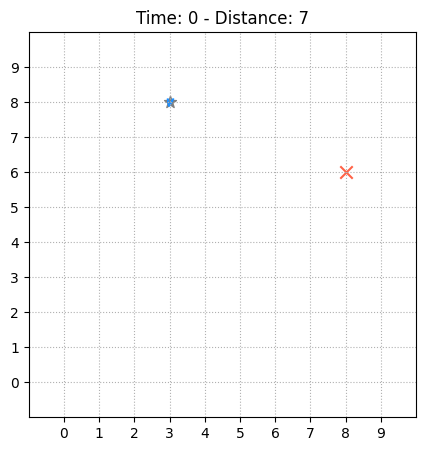

In [14]:
state, dist = env.initialize()
print(f"Posicion vehiculo: {state["vehicle"]}")
print(f"Posicion objetivo: {state["target"]}")
print(f"Distancia: {dist}")
print(f"Tiempo transcurrido: {env.time}")
graf_grid(env.size, env.time, dist, state, state)

Guarda la posición del vehículo en una lista llamada `trace`. Esta nos será util para las posteriores visualizaciones.

In [15]:
trace = [state["vehicle"].tolist()]

Movamos el vehículo de manera aleatoria. Para esto escoge una acción del espacio de acciones mediante el método `action_space.sample` y posteriormente actualiza el entorno con `step`.  

In [16]:
action = env.action_space.sample()
if action == 0:
    print("Accion: este")
elif action == 1:
    print("Accion: norte")
elif action == 2:
    print("Accion: oeste")
elif action == 3:
    print("Accion: sur")

new_state, reward, end_sim, end_time, dist = env.step(action)
print(f"Posicion vehiculo: {new_state["vehicle"]}")
print(f"Posicion objetivo: {new_state["target"]}")
print(f"Distancia: {dist}")
print(f"Tiempo transcurrido: {env.time}")

Accion: este
Posicion vehiculo: [4 8]
Posicion objetivo: [8 6]
Distancia: 6.0
Tiempo transcurrido: 1


Adiciona esta posición en `trace` y visualiza el entorno.

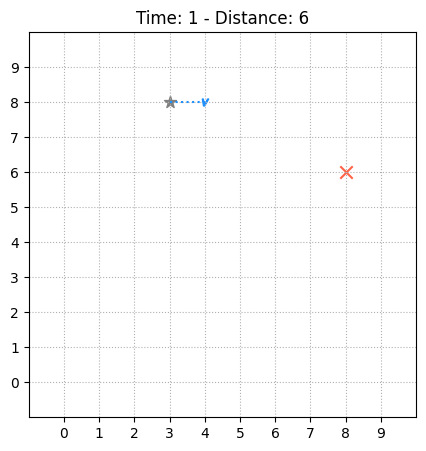

In [17]:
trace.append(new_state["vehicle"].tolist())
graf_grid(env.size, env.time, dist, state, new_state, trace = np.array(trace))

Mediante un bucle `while`, repite este procedimiento hasta que se alcance el objetivo o se llegue al tiempo límite. Luego visualiza el entorno.

In [18]:
# Realizar una simulacion hasta que se cumpla el tiempo o se alcance el objetivo
final = False

while not final:
    action = env.action_space.sample() 
    new_state, reward, end_sim, end_time, dist = env.step(action)
    trace.append(new_state["vehicle"].tolist())
    final = end_sim or end_time

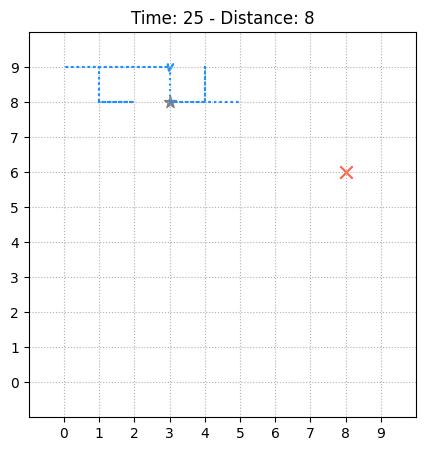

In [19]:
# Visualizar el entorno
graf_grid(env.size, env.time, dist, state, new_state, trace = np.array(trace))

Nuestro vehículo se comporta de manera errática y probablemente no fue capaz de alcanzar el destino objetivo. Esto es esperable considerando que la política de decisión de las acciones que hemos utilizados es aleatoria al ser un modelo base.

Repite este ejercicio 1,000 veces para calcular la tasa de éxito del agente, es decir, el porcentaje de ocasiones que el vehículo es capaz de alcanzar el objetivo con este modelo. También estima el tiempo medio de cada simulación como razón de la distancia inicial de cada simulación. Para esto, deberás inicializar en cada intento el entorno.

In [20]:
# Ejecutar 1000 simulaciones
simulations = 1000
total_reward = []
total_time = []

for _ in range(simulations):

    state, dist_ini = env.initialize()
    reward_sim = 0
    final = False

    while not final:
        action = env.action_space.sample() 
        state, reward, end_sim, end_time, dist = env.step(action)
        final = end_sim or end_time
        reward_sim = reward_sim + reward
    
    total_reward.append(reward_sim)
    total_time.append(env.time / dist_ini - 1)

In [21]:
# Calcular tasa de exito y tiempo medio
win_rate = np.mean(total_reward)
tiempo_medio = np.mean(total_time)
print(f"Tasa de exito: {win_rate:.1%}")
print(f"Tiempo medio: {tiempo_medio:.1%}")

Tasa de exito: 12.2%
Tiempo medio: 370.3%


Estos resultados se constituyen en nuestras métricas de rendimiento. En consecuencia, vamos a definir un mejor algoritmo de optimización que incremente la tasa de éxito, a su vez que disminuya el tiempo recorrido.

## Creación de modelo con algoritmo Q-Learning

El algoritmo **Q-Learning** fue desarrollado por Christopher Watkins y Peter Dayan con el propósito de encontrar una política de estrategías óptima mediante la lógica de prueba y error ante el surgimiento de escenarios dinámicos en un entorno como el que hemos creado.

La idea detrás de este algoritmo es crear una tabulación cruzada de valores llamados **quality values** para cada una de las acciones en un estado específico del entorno, de modo que el agente cuente con este insumo para escoger aquella acción de mayor calidad en cualquier escenario. Para construir este matriz es importante que el agente "explore" y pruebe muchas opciones posibles; y una vez que ha explorado lo suficiente, "explote" este conocimiento para decidir de manera eficiente.

Lo anterior conlleva que si bien se pueden alcanzar buenos resultados con la aplicación de este algoritmo, los tiempos de entrenamiento (exploracion) pueden ser excesivamente altos dependiendo de la cantidad de acciones y escenarios posibles del entorno.

Veamos entonces como construir un modelo de **Aprendizaje por refuerzo** con este algoritmo paso a paso. Para empezar, define en `dic_qval` un diccionario dinamico con la función `defaultdict` y el argumento `lambda: np.zeros(4)`, que representa los q-valores de cada posible acción. 

In [22]:
dic_qval = defaultdict(lambda: np.zeros(4))

Planteemos ahora la lógica de "exploración"-"explotación" que debe seguir nuestro modelo, para lo cual utilizaremos el **criterio $\epsilon$-codicioso**. Este criterio indica que en cada paso de una simulación, el agente (vehículo) tomará una acción al azar con una probabilidad $\epsilon$, mientras que con una probabilidad $1-\epsilon$ escojerá la acción de mayor q-valor para el estado en el que se encuentre. Define entonces la funcion `select_action` con este criterio.

In [23]:
def select_action (current_state, epsilon):

    # Ejecutar exploracion con probabilidad epsilon
    if np.random.random() < epsilon:
        action = env.action_space.sample() 
    # Ejecutar explotacion con probabilidad 1 - epsilon
    else:
        action = int(np.argmax(dic_qval[current_state]))

    return action

Complementa el criterio con la función auxiliar `update_espilon` que reciba como entradas $\epsilon$, $\delta$ y $\epsilon_m$; y actualice el primero de estos valores a $\max{(\epsilon - \delta, \epsilon_m)}$. Lo anterior nos permitirá regular el cambio de lógica del agente de "exploración" a "explotación" durante el entrenamiento. 

In [24]:
def update_epsilon (epsilon, delta, min_epsilon):
    epsilon = max(epsilon - delta, min_epsilon)

Finalmente, crea la función `update_qval` que nos permita actualizar los q-valores ($q_{a,s}$) dependiendo de la acción ($a$) y los estados actual ($s$) y siguiente ($s'$) que realice el agente. Para esto considera la ecuación

$$ q_{s,a}^{n} = q_{s,a}^{c} + \tau \left[ r_{s,a} + \beta \max{(Q_{s'})} - q_{s,a}^{c} \right] $$

donde:

* $q_{s,a}^{n}$ es el q-valor a asignar para el estado $s$ y la acción $a$.
* $q_{s,a}^{c}$ es el q-valor actual para el estado $s$ y la acción $a$.
* $\tau$ es una tasa de aprendizaje que regula la actualización del q-valor.
* $r_{s,a}$ es la recompensa obtenida en el estado $s$ y la acción $a$.
* $\beta$ es una tasa de descuento que toma un valor positivo y menor o igual a 1 cuando se está dando la simulación (0 cuando la simulación ha terminado). 
* $Q_{s'}$ es el vector de q-valores para el estado $s'$.

Esta fórmula se conoce como **Ecuación de Bellman**, y sirve para realizar actualizaciones de valores en problemas asociados a programación dinámica como el que estamos realizando.

In [25]:
def update_qval (current_state, new_state, action, reward, final, tau, beta):
     
    # Extraer q-valor del estado actual y accion
    current_q = dic_qval[current_state][action]

    # Estimar nuevo q-valor con la ecuacion de Bellman
    bellman_e = reward + beta * (1 - final) * np.max(dic_qval[new_state]) - current_q
    dic_qval[current_state][action] = current_q + tau * bellman_e

Con estos insumos crea la clase `QLearn` que reciba como entrada lo siguiente:

* Un entorno como el creado por nosotros. 
* $\epsilon = 1.0$. 
* $\delta = 0.01$.
* $\epsilon_m = 0.1$.
* $\tau = 0.01$.
* $\\beta = 1.0$   

Esta clase debe contener como métodos las 3 funciones antes definidas.

In [26]:
class QLearn():

    # Definir atributos del entorno
    def __init__ (
            self, 
            env,
            epsilon = 1.0,
            delta = 0.01,
            min_epsilon = 0.1,
            tau = 0.01,
            beta = 1.0
    ):

        self.dic_qval = defaultdict(lambda: np.zeros(4))
        self.env = env
        self.epsilon = epsilon
        self.delta = delta
        self.min_epsilon = min_epsilon
        self.tau = tau
        self.beta = beta
    
    # Definir metodo para seleccionar accion
    def select_action (self, current_state):

        if np.random.random() < self.epsilon:
            action = self.env.action_space.sample() 
        else:
            action = int(np.argmax(self.dic_qval[current_state]))

        return action
    
    # Definir metodo para actualizar epsilon
    def update_epsilon (self):
        self.epsilon = max(self.epsilon - self.delta, self.min_epsilon)
    
    # Definir metodo para actualizar q-valores
    def update_qval (self, current_state, new_state, action, reward, final):
        
        current_q = self.dic_qval[current_state][action]
        bellman_e = reward + self.beta * (1 - final) * np.max(self.dic_qval[new_state]) - current_q
        self.dic_qval[current_state][action] = current_q + self.tau * bellman_e        

Para asimilar con los conceptos vistos hasta ahora, notemos que todas las entradas de esta clase, con excepción del entorno, se corresponden con los **hiperparámetros** que como científicos de datos podemos regular y controlar *a priori* para optimizar nuestro algoritmo.

Prueba todo esto creando un modelo basado en el algoritmo Q-Learning. Utiliza como argumentos `delta = 1/50000`, `tau = 0.001` y `beta = 0.95`.

In [27]:
# Crear un nuevo entorno
env = CityEnv()

# Crear un modelo con Q-Learning
modelo = QLearn(
    env,
    delta = 1/50000,
    tau = 0.001,
    beta = 0.95
)

Es momento de entrenar el modelo. Realiza 100,000 simulaciones de busqueda de rutas para el vehiculo y en cada una de ellas has lo siguiente: 

* Durante cada paso, selecciona una acción con el método `select_action` del modelo basado en Q-Learning.
* Durante cada paso, actualiza los q-valores con el método `update_qval`.
* Concluidos todos los pasos, actualiza el $\epsilon$ con el método `update_epsilon`. 
* Guarda en una lista las recompensas y el tiempo de la simulación.

In [28]:
simulations = 100000
train_reward = []
train_time = []

for _ in range(simulations):

    # Inicializar el entorno
    current_state, dist_ini = env.initialize()
    current_state_t = tuple([tuple(current_state["vehicle"].tolist()), tuple(current_state["target"].tolist())])
    final = False
    reward_sim = 0

    # Ejecutar simulacion y actualizar q-valores
    while not final:

        # Seleccionar una accion
        action = modelo.select_action(current_state_t)

        # Ejecutar el paso con la accion seleccionada y actualizar valores
        new_state, reward, end_sim, end_time, dist = env.step(action)
        new_state_t = tuple([tuple(new_state["vehicle"].tolist()), tuple(new_state["target"].tolist())])
        final = end_sim or end_time
        reward_sim = reward_sim + reward
        modelo.update_qval(current_state_t, new_state_t, action, reward, final)
        current_state = new_state
        current_state_t = tuple([tuple(current_state["vehicle"].tolist()),tuple(current_state["target"].tolist())])
    
    # Actualizar epsilon
    modelo.update_epsilon()

    # Guardar resultados de recompensa y tiempo
    train_reward.append(reward_sim)
    train_time.append(env.time / dist_ini - 1)

Evalúa el rendimiento de este modelo visualizando una media movil de las recompensas alcanzadas en las iteraciones. Utiliza para esto la funcion `np.convolve` y una ventana de 1,000.

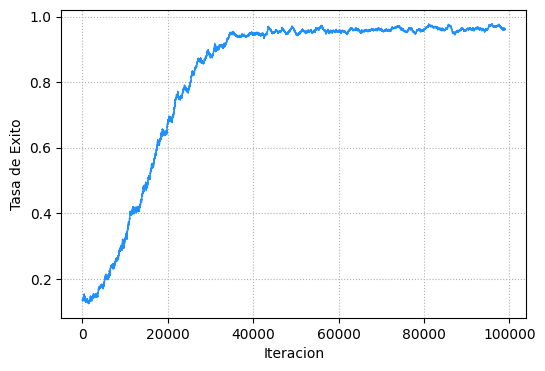

In [29]:
reward_ma = np.convolve(a = train_reward, v = np.ones(1000), mode = "valid") / 1000
plt.figure(figsize = [6,4])
plt.plot(
    reward_ma,
    color = "dodgerblue",
    linewidth = 1
)
plt.xlabel("Iteracion")
plt.ylabel("Tasa de Exito")
plt.grid(linestyle = ":")
plt.show()

In [30]:
# Obtener tasa de éxito de últimas 1000 iteraciones
print(f"Tasa de exito: {reward_ma[-1]:.1%}")

Tasa de exito: 96.1%


Has lo mismo con el tiempo de las simulaciones relativo a la distancia inicial.

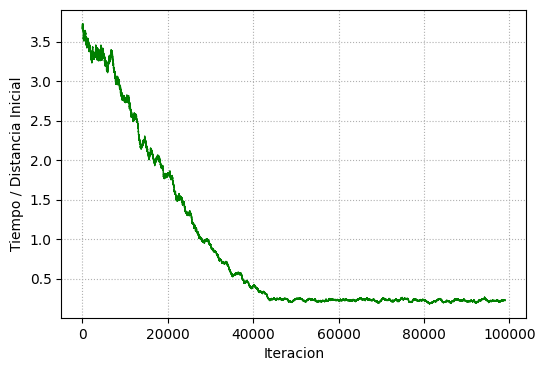

In [31]:
time_ma = np.convolve(a = train_time, v = np.ones(1000), mode = "valid") / 1000
plt.figure(figsize = [6,4])
plt.plot(
    time_ma,
    color = "green",
    linewidth = 1
)
plt.xlabel("Iteracion")
plt.ylabel("Tiempo / Distancia Inicial")
plt.grid(linestyle = ":")
plt.show()

In [32]:
# Obtener tiempo medio de últimas 1000 iteraciones
print(f"Tiempo medio: {time_ma[-1]:.1%}")

Tiempo medio: 22.0%


Si todo fue realizado correctamente notarás que a partir de iteración 50,000 aproximadamente el rendimiento del modelo creado se estabiliza alcanzando una tasa de éxito cercana al 100% y un tiempo de viaje cercano a este valor. En otras palabras, el modelo a permitido encontrar una estrategia óptima para que el vehículo llegue a su destino objetivo independiente de su posición inicial, y en un tiempo aceptable.

Verifica lo anterior "explotando" el modelo para la selección de una ruta óptima. Modifica con este propósito el atributo `epsilon`.

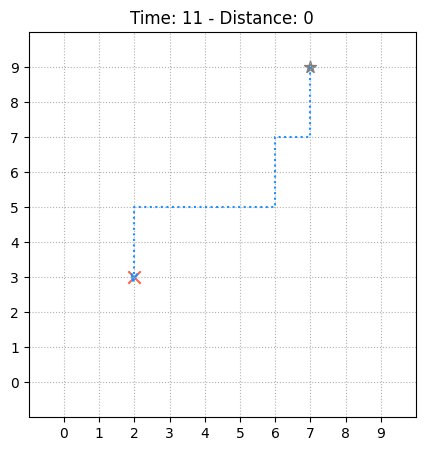

In [33]:
# Crear modelo optimo con QLearn
modelo_optimo = modelo
modelo_optimo.epsilon = 0 # Completa explotacion

# Testear modelo
orig_state, dist = env.initialize()
state_t = tuple([tuple(orig_state["vehicle"].tolist()),tuple(orig_state["target"].tolist())])
final = False
trace = [orig_state["vehicle"].tolist()]

while not final:
    action = modelo_optimo.select_action(state_t)
    state, reward, end_sim, end_time, dist = env.step(action)
    state_t = tuple([tuple(state["vehicle"].tolist()),tuple(state["target"].tolist())])
    final = end_sim or end_time  
    trace.append(state["vehicle"].tolist())

graf_grid(env.size, env.time, dist, orig_state, state, trace = np.array(trace))

Para concluir, vamos a estudiar más a fondo la complejidad asociada a nuestro modelo y la política estratégica que se define. En primera instancia crea un dataframe que contenga los q-valores para cada una de los estados explorados, así como las posiciones en "x" y "y" del objetivo relativo al vehículo.

In [34]:
df_qval = pd.DataFrame(
    np.array(list(modelo_optimo.dic_qval.values())),
    index = modelo_optimo.dic_qval.keys()
)

explored_s = list(modelo_optimo.dic_qval.keys())

explored_rel = []

for s in explored_s:
    v = list(np.array(s[1]) - np.array(s[0]))
    explored_rel.append(v)

explored_rel = np.array(explored_rel)

df_qval["dx"] = explored_rel[:,0]
df_qval["dy"] = explored_rel[:,1]

df_qval.sample(5)


,,0,1,2,3,dx,dy
"(1, 0)","(7, 7)",3.757110e-23,5.205136e-27,2.130379e-32,0.000000e+00,6,7
"(4, 0)","(1, 9)",7.444743e-35,1.825592e-18,0.000000e+00,0.000000e+00,-3,9
"(4, 9)","(4, 0)",1.325388e-23,3.260354e-34,3.115379e-27,2.293624e-16,0,-9
"(1, 3)","(7, 0)",2.649492e-14,2.204343e-25,2.639471e-21,5.303315e-21,6,-3
"(0, 7)","(4, 5)",1.669793e-14,3.209549e-22,8.797748e-17,3.592768e-11,4,-2


Observa el tamaño de esta tabla y determina la cantidad de q-valores que tuvo que estimar el modelo. Lo anterior a fin de darnos una idea de la complejidad asociada a la aplicación de este algoritmo.

In [35]:
# Estimar tamaño de la tabla de q-valores
print(f"Filas: {df_qval.shape[0]:,.0f}")
print(f"Columnas: {df_qval.shape[1]:,.0f}")

# Calcular q-valores estimados en el modelo 
print(f"q-valores estimados: {df_qval.shape[0] * (df_qval.shape[1] - 2):,.0f}")

Filas: 10,000
Columnas: 6
q-valores estimados: 40,000


En otras palabras, este modelo ha generado y entrenado 40,000 parámetros. Un valor extremadamente alto si lo comparamos con otros metodos tradicionales del aprendizaje computacional. De hecho, este número de parámetros seguramente los has visto en modelos basados en redes neuronales, lo cual te debería dar una idea de cómo funcionan otros algoritmos en el contexto del **Aprendizaje por refuerzo**.  

Agrupa ahora esta información por las posiciones relativas y obten el q-valor promedio para cada una de las acciones posibles.

In [36]:
df_qval_pos = (
    df_qval
    .groupby(["dx", "dy"])
    .agg(
        e = (0,"mean"),
        n = (1,"mean"),
        w = (2,"mean"),
        s = (3,"mean")
    ).
    reset_index()
)

Adiciona una columna que indique "e" si el q-valor máximo corresponde a la acción de ir al este (0), "n" para la acción de ir al norte, "w" para para acción de ir al oeste, o "s" para la acción de ir al sur. 

In [37]:
df_qval_pos["direction"] = df_qval_pos[["e","n","w","s"]].max(axis = 1)

def fun_max (row):
    if row["direction"] == row["e"]:
        return "e"
    elif row["direction"] == row["n"]:
        return "n"
    elif row["direction"] == row["w"]:
        return "w"
    else:
        return "s"

df_qval_pos["direction"] = df_qval_pos.apply(fun_max, axis = 1)
df_qval_pos.sample(5)

,dx,dy,e,n,w,s,direction
31,-8,3,3.326992e-26,2.985028e-18,3.983651e-18,1.471649e-20,w
198,1,-1,7.069787e-03,3.305442e-06,1.138765e-06,1.119874e-02,s
301,6,7,2.741828e-21,3.561192e-20,3.879620e-26,2.073730e-26,n
64,-6,-2,4.373731e-15,3.851344e-15,7.413022e-12,6.952964e-10,s
204,1,5,4.622962e-08,5.947891e-08,9.235731e-13,6.518765e-13,n


Con esta información, crea un gráfico que muestre la acción que tomará el vehículo en función de la posición relativa del objetivo. 

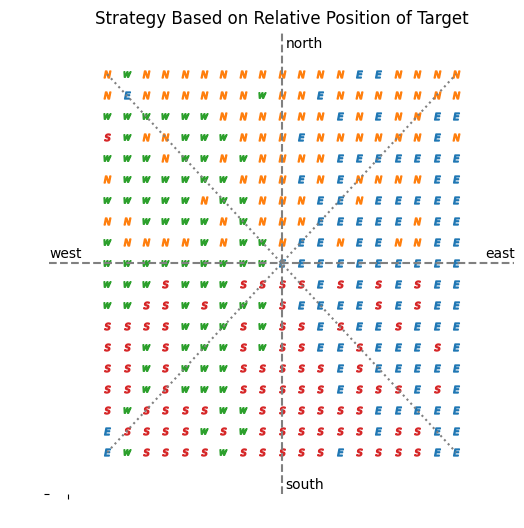

In [38]:
dic_point = {"e": "$E$", "n": "$N$", "w": "$W$", "s": "$S$"}
dic_color = {"e": "C0", "n": "C1", "w": "C2", "s": "C3"}

fig, ax = plt.subplots(figsize = [6,6])

for lab, group in df_qval_pos.groupby("direction"):
    group.plot(
        kind = "scatter",
        x = "dx",
        y = "dy",
        ax = ax,
        marker = dic_point[lab],
        c = dic_color[lab],
        s = 25
    ) 
for spine in ax.spines.values():
    spine.set_visible(False)
plt.plot(df_qval_pos["dy"], df_qval_pos["dy"], color = "gray", linestyle = ":")
plt.plot(df_qval_pos["dy"], -df_qval_pos["dy"], color = "gray", linestyle = ":")
plt.title("Strategy Based on Relative Position of Target")
plt.xlabel("")
plt.ylabel("")
plt.axhline(y = 0, color = "gray", linestyle = "--")
plt.annotate(text = "north", xy = [0.2, env.size + 0.25])
plt.annotate(text = "south", xy = [0.2, -1 * env.size - 0.75])
plt.axvline(x = 0, color = "gray", linestyle = "--")
plt.annotate(text = "east", xy = [env.size + 0.5, 0.25])
plt.annotate(text = "west", xy = [-1 * env.size - 2, 0.25])
plt.xticks(ticks = range(-1 * env.size - 1, env.size + 1, 100), color = "white")
plt.xlim([-12, 12])
plt.yticks(ticks = range(-1 * env.size - 1, env.size + 1, 100), color = "white")
plt.ylim([-11, 11])
plt.show()

La estrategia obtenida es bastante consistente con la lógica humana. Por ejemplo, si el objetivo se encuentra al norte del vehículo, este decidirá ir en esa dirección para acerecarse a su destino; lo mismo sucede en cualquiera de las otras 3 posiciones relativas "absolutas" (este, oeste o sur). En casos donde el objetivo esté en posiciones "mixtas" (i.e. noreste), el agente combinará acciones entre ir al norte o ir al este.

¡Todo terminado! Ya has diseñado creado y optimizado un proyecto piloto con un modelo capaz de encontrar rutas óptimas. La empresa que te contrató estará satisfecha y seguramente dará luz verde a otras iniciativas que le permitan adaptar nuevas tecnologías en sus productos. 